# Performance comparison
Here we walk through the necessary steps to reproduce the main figures of the performance comparison of different RBP datasets across cell lines using BRIDGE.

## 1. Load BRIDGE model and compute metrics
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the BRIDGE metrics.

In [1]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/validate_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running validate for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --validate \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 0 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running validate for: AARS_K562
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15000 sequences for AARS_K562, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/output/AARS_K562/output/STRME_training_set.tab
AARS_K562 auc: 0.7972 acc: 0.7737 auprc: 0.7224 mcc: 0.4605
Running validat

In [2]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
LOG="results/logs/validate_all.log"
OUT="results/benchmarks/BRIDGE_auc.tsv"
mkdir -p results/benchmarks

echo -e "RBP_Cell\tBRIDGE" > "$OUT"

grep -E '^[A-Za-z0-9]+_[A-Za-z0-9]+ auc:' "$LOG" \
  | awk '{print $1 "\t" $3}' \
  >> "$OUT" || true

echo "Wrote: $OUT"
cat "$OUT"

Wrote: results/benchmarks/BRIDGE_auc.tsv
RBP_Cell	BRIDGE
AARS_K562	0.7972
AUH_HepG2	0.8979
AUH_K562	0.9265


## 2. Downstream analysis of cell type-specific BRIDGE results
### Performance comparison of different RBP datasets across cell lines
Here we walk through the necessary steps to generate the circos plot for the AUPRC metric.

```{important}
**How to use R code in this notebook?**

We have developed several R scripts to perform downstream analyses, and the essential code for key analyses is provided below. To interactively execute the analysis within this notebook, we utilize the `rpy2` package, which allows running R code directly. Thus, please ensure that `rpy2` is installed (`conda install conda-forge::rpy2`). Alternatively, you may extract these R scripts and execute them externally as standalone R scripts.

The code below initializes `rpy2`. After this setup, you can write and execute R code directly within notebook cells by starting with `%%R`.
```

In [3]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

#### Load required packages

To completely finish the following analysis, you need requires specific R packages listed below (`pkgs`), and you can verify and install using the code provided below.

Installing with conda solves most of the dependency package installation problems:
```
conda install -y bioconductor-complexheatmap
```

The other packages can be installed just in R:

```
install.packages("circlize")
```

In [4]:
%%R
library(circlize)
library(ComplexHeatmap)

#### Load precomputed results for BRIDGE and other methods
```{note}
Running BRIDGE on the full dataset can take a long time. For convenience, we also provide the precomputed results for BRIDGE and all baseline methods on Figshare as `AUPRC_baselines.metrics`, which you can download directly.

You can modify `base_path` below to change where the data is stored.
```

In [14]:
%%R
base_path <- dirname(dirname(getwd()))
data <- read.table(
  paste0(base_path, "/results/metrics/AUPRC_baselines.metrics"),
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)
head(data)

         RBP_Cell BRIDGE HDRNet PrismNet DeepRiPe GraphProt2 DeepBind DeepCLIP
1      AGO_HEK293 0.9113 0.8797   0.7300   0.8161     0.6443   0.6505   0.5882
2   ALKBH5_HEK293 0.7036 0.6560   0.6753   0.6006     0.5789   0.5802   0.5817
3 C17ORF85_HEK293 0.7479 0.5539   0.5776   0.6060     0.4669   0.4440   0.3941
4 C22ORF28_HEK293 0.8077 0.7715   0.7210   0.6273     0.5728   0.5246   0.5099
5  CAPRIN1_HEK293 0.7715 0.6263   0.6078   0.5973     0.5242   0.5365   0.5319
6    CPSF1_HEK293 0.7383 0.6366   0.6351   0.5772     0.5854   0.5653   0.5491
  iDeepE
1 0.6383
2 0.5913
3 0.6666
4 0.6666
5 0.6666
6 0.6666


#### Convert data format

In [15]:
%%R
# Set row names as the first column
rownames(data) <- data[, 1]
data <- data[, -1]
mat <- as.matrix(data) # data to matrix
dim(mat)

# assign rownames as split variable
split <- as.factor(rownames(data))

**Color mapping**

In [16]:
%%R
# Define a color ramp function for visualizing a matrix 'mat'
col_fun = colorRamp2(c(min(mat),  0.75, 0.81, 0.86, max(mat)),
                    c("#17336e","#b7d8eb", "#ffffff", "#fdfde8", "#fd3021"))

#### The plotting function

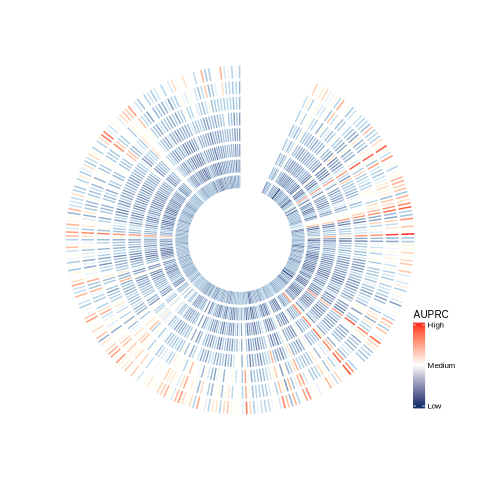

In [17]:
%%R
# init circos plot
circos.clear()
# Set parameters for the circos plot
circos.par(
  canvas.xlim = c(-1.2, 1.2), # set x-axis range
  canvas.ylim = c(-1.2, 1.2), # set y-axis range
  clock.wise = FALSE, # set clockwise direction
  start.degree = 90, # set start angle
  gap.after = c(rep(1, length(rownames(data))-1), 25) # set gap between tracks
)

# plot heatmap for each column
# Loop through each column of the matrix 'mat' to create individual heatmaps in a circos plot
for (i in 1:ncol(mat)) {
  # Create a heatmap for the current column of 'mat' using the circos.heatmap function
  circos.heatmap(
    mat[, i, drop = FALSE], 
    split = split, 
    col = col_fun, 
    cluster = FALSE, 
    track.height = 0.07
  )
}

# draw legend
lgd <- Legend(
  at = c(0, 0.5, 1),
  labels = c("Low", "Medium", "High"),
  col_fun = colorRamp2(
    c(0, 0.5, 1),
    c("#17336e", "#ffffff", "#fd3021")
  ),
  title = "AUPRC",
  direction = "vertical",
  title_gp = gpar(fontsize = 10),
  labels_gp = gpar(fontsize = 8),
  legend_height = unit(3, "cm")
)

# set legend position and draw
draw(
  lgd,
  x = unit(0.95, "npc"),
  y = unit(0.15, "npc"),
  just = c("right", "bottom")
)

circos.clear()